# Assignment 1 - Unsupervised Learning Methods
## Task 1: Data Loading and Exploration
**Dataset:** Heart Disease UCI (`processed.cleveland.data`)  
**Goal:** Load the dataset, inspect its structure, handle missing values, visualise feature distributions, and analyse correlations.

---
### 1.1 Imports and Library Setup

Load generic libraries as well as the `ucimlrepo`for loading the data. Setup the aesthetics environment for the entire notebook.

In [1]:
pip install ucimlrepo


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard data-science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib as mpl

from ucimlrepo import fetch_ucirepo


# Reproducibility
np.random.seed(42)

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
PALETTE = ['#4A90D9', '#E8603C', '#2EAF7D', '#9B59B6', '#F39C12', '#C0392B', '#1ABC9C']

PALETTE_SEQ = 'YlOrRd'
PALETTE_DIV = 'coolwarm'

# Global style
sns.set_theme(
    style='whitegrid',
    palette=PALETTE,
    font='DejaVu Sans',
    font_scale=1.1,
    rc={
        'figure.dpi': 120,
        'figure.figsize': (10, 5),
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titleweight': 'bold',
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.frameon': False,
        'legend.fontsize': 9,
    }
)

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=PALETTE)

---
### 1.2 Load Dataset

Loading the dataset directly from its library.

In [4]:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

### Target Variable
| Variable | Description | Values |
|---|---|---|
| `num` | Diagnosis of heart disease (angiographic disease status) | 0 = <50% diameter narrowing (no disease); 1–4 = >50% narrowing (disease present) |

---

### Feature Descriptions

#### Demographic Features
| Variable | Description |
|---|---|
| `age` | Age in years |
| `sex` | Biological sex (1 = male, 0 = female)|

#### Symptoms and Clinical Presentation
| Variable| Description | Typical / Reference Values |
|---|---|---|
| `cp`| Chest pain type | 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic|
| `exang`| Exercise-induced angina | 1 = yes, 0 = no|

#### Resting Measurements
| Variable| Description | Typical / Reference Values |
|---|---|---|
| `trestbps`| Resting blood pressure on hospital admission (mm Hg) | Normal: <120 mm Hg; Hypertension stage 1: 130–139 mm Hg ³|
| `chol`| Serum cholesterol (mg/dl) | Desirable: <200 mg/dl; Borderline high: 200–239; High: ≥240 mg/dl ⁴|
| `fbs`| Fasting blood sugar >120 mg/dl | 1 = true, 0 = false.|
| `restecg`| Resting electrocardiographic results | 0 = normal; 1 = ST-T wave abnormality; 2 = left ventricular hypertrophy (LVH) by Estes' criteria ⁵|

#### Stress Test Measurements
| Variable| Description | Typical / Reference Values |
|---|---|---|
| `thalach`| Maximum heart rate achieved during stress test (bpm) | Age-predicted max HR ≈ 220 - age ⁶|
| `oldpeak`| ST depression induced by exercise relative to rest (mm) | 0 = no depression; values >2 mm considered clinically significant for ischaemia. ² |
| `slope`| Slope of the peak exercise ST segment | 1 = upsloping (generally normal); 2 = flat; 3 = downsloping (most concerning, associated with ischaemia) ² |

#### Diagnostic Test Results
| Variable| Description | Typical / Reference Values |
|---|---|---|
| `ca` | Number of major vessels (0–3) coloured by fluoroscopy | 0 = no vessels narrowed; higher values indicate more extensive coronary artery disease ⁵|
| `thal`| Thalassemia / myocardial perfusion type | 3 = normal; 6 = fixed defect (permanent damage); 7 = reversible defect ⁵ |

In [5]:
print(f'Features: {X.shape[0]} rows × {X.shape[1]} columns')
print(f'Target: {y.shape[0]} rows × {y.shape[1]} columns')

Features: 303 rows × 13 columns
Target: 303 rows × 1 columns


In [6]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


---
### 1.3 Dataset Shape, Data Types and Summary Statistics

In [7]:
print('=== Data Types ===')
print('Features')
print(X.dtypes)
print()
print('Target')
print(y.dtypes)

=== Data Types ===
Features
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Target
num    int64
dtype: object


In [8]:
print('=== Summary Statistics ===')
X.describe()

=== Summary Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


**Comments on summary statistics**

**`age`**: Mean ≈ 54.4 years (SD = 9.0), range 29–77. The IQR spans 48–61, meaning the middle 50% of patients are in their late 40s to early 60s. ¹ Near-symmetric distribution (mean ≈ median = 56).

**`sex`**: Mean = 0.68 → **68% of patients are male**. Higher prevalence and earlier onset of CAD in men. Demographic imbalance to keep in mind when interpreting clusters.¹

**`cp`**: Mean = 3.16, median = 3 → most patients present with **non-anginal pain (3) or asymptomatic (4)**. The 75th percentile is 4, meaning at least 25% of patients are asymptomatic.

**`trestbps`**: Mean ≈ 131.7 mm Hg, which falls in the hypertension stage 1 range (130-139 mm Hg). ³ Max = 200 mm Hg suggests some patients with severe hypertension.

**`chol`** Mean ≈ 246.7 mg/dl in borderline high by clinical standards (≥240 mg/dl). ⁴ Max = 564 mg/dl far ourside the normal range. The wide SD (51.8) and right-skewed distribution.

**`fbs`**: Mean = 0.15 -> only ~15% of patients have fasting blood sugar >120 mg/dl. Low variance (most values = 0).

**`restecg`**: Mean ≈ 0.99, median = 1 -> divided between normal (0) and ST-T wave abnormality (1), with very few LVH cases (2)(75th percentile = 2).

**`thalach`**: Mean ≈ 149.6 bpm, with a range of 71-202.

**`exang`**: Mean = 0.33 -> ~33% of patients experience exercise-induced angina.

**`oldpeak`**: Mean = 1.04, median = 0.8, max = 6.2. The mean > median indicates right-skewed distribution with long tail.


**`slope`**: Mean = 1.6, median = 2 -> most patients fall in the **flat (2)** category. The 25th percentile = 1 (upsloping) and 75th = 2 (flat), with downsloping (3) being the least common in this dataset.

**`ca`**: Mean = 0.67, median = 0, indicates that the majority of patients have 0 vessels narrowed. The distribution is right-skewed with most mass at 0.

**`thal`**: The 25th and 50th percentiles = 3 (normal), 75th = 7 (reversible defect).

---
### 1.4 Missing Value Analysis and Handling Strategy

In [9]:
missing_feat = X.isnull().sum()
missing_pct = (missing_feat / len(X) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing_feat, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== Missing Features ===')
print(missing_df)
print(f'\nTotal rows before cleaning: {len(X)}')


missing_targ = y.isnull().sum()
print('Missing Targets:', missing_targ)

=== Missing Features ===
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66

Total rows before cleaning: 303
Missing Targets: num    0
dtype: int64


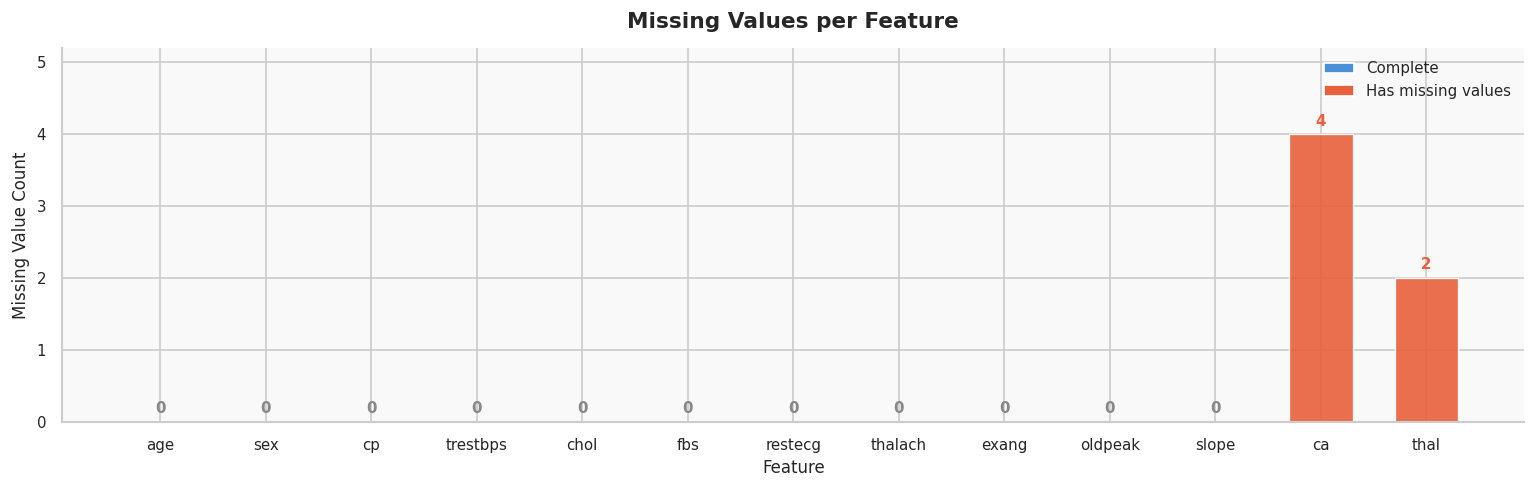

In [10]:
missing_all = X.isnull().sum().reindex(X.columns)

fig, ax = plt.subplots(figsize=(13, 4.5))

colors = [PALETTE[1] if v > 0 else PALETTE[0] for v in missing_all.values]
bars = ax.bar(missing_all.index, missing_all.values,
              color=colors, edgecolor='white', linewidth=0.8,
              width=0.6, alpha=0.9, zorder=2)

# Value labels
for bar, val in zip(bars, missing_all.values):
    label_color = PALETTE[1] if val > 0 else '#888888'
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            str(val), ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=label_color)

# Subtle reference line at 0
ax.axhline(0, color='#cccccc', linewidth=0.8, zorder=1)

ax.set_ylim(0, missing_all.max() + 1.2)
ax.set_ylabel('Missing Value Count', fontsize=10)
ax.set_xlabel('Feature', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.set_facecolor('#f9f9f9')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE[0], label='Complete'),
    Patch(facecolor=PALETTE[1], label='Has missing values'),
]
ax.legend(handles=legend_elements, fontsize=9,
          facecolor='white', edgecolor='#dddddd', framealpha=0.9)

ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Missing value strategy**


Only `ca` (4 missing, 1.32%) and `thal` (2 missing, 0.66%) have missing values.
Together this is only 6 rows out of 303 (< 2%).

Three strategies were considered:

| Strategy | Description |
|---|---|
| **Listwise deletion** | Drop the 6 affected rows entirely |
| **Mode imputation** | Replace missing values with the most frequent category |
| **KNN imputation** | Infer missing values from the k nearest neighbours |

Listwise deletion produces unbiased estimates when missingness is small and not systematically related to the outcome ⁷. Dropping them introduces no meaningful loss of statistical power, 297 samples remain.

Moreover, `ca` and `thal` are categorical/ordinal features, but the other imputation methods commented are designed for continuous data.



In [11]:
# Get index of rows with no missing values in X
valid_idx = X.dropna().index

X = X.loc[valid_idx].reset_index(drop=True)
y = y.loc[valid_idx].reset_index(drop=True)

print(f'Rows after dropping missing values: {len(X)}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Rows after dropping missing values: 297
X shape: (297, 13)
y shape: (297, 1)


---
### 1.5 Target Distribution

In [12]:
y = (y > 0).astype(int)

print(f'Feature matrix X: {X.shape}')
print(f'Target vector y:  {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Disease (1)'}))

Feature matrix X: (297, 13)
Target vector y:  (297, 1)

Target distribution:
num           
No Disease (0)    160
Disease (1)       137
Name: count, dtype: int64


**Balancing**


The dataset is moderately balanced, roughly 54% no-disease vs 46% disease.

---
### 1.6 Visualization

A more extensive classification is done in Task 2, but in order to apply appropriate visualisations, they are divided now in contiuous and numerical, and binary, ordinal and categorical.

In [13]:
# Continuous/numerical features (suitable for histogram + boxplot)
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Binary / ordinal / categorical features (suitable for bar plot)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print('Continuous features: ', continuous_features)
print('Categorical features:', categorical_features)

Continuous features:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


---
### 1.7 Feature Distributions

#### Continuous Features

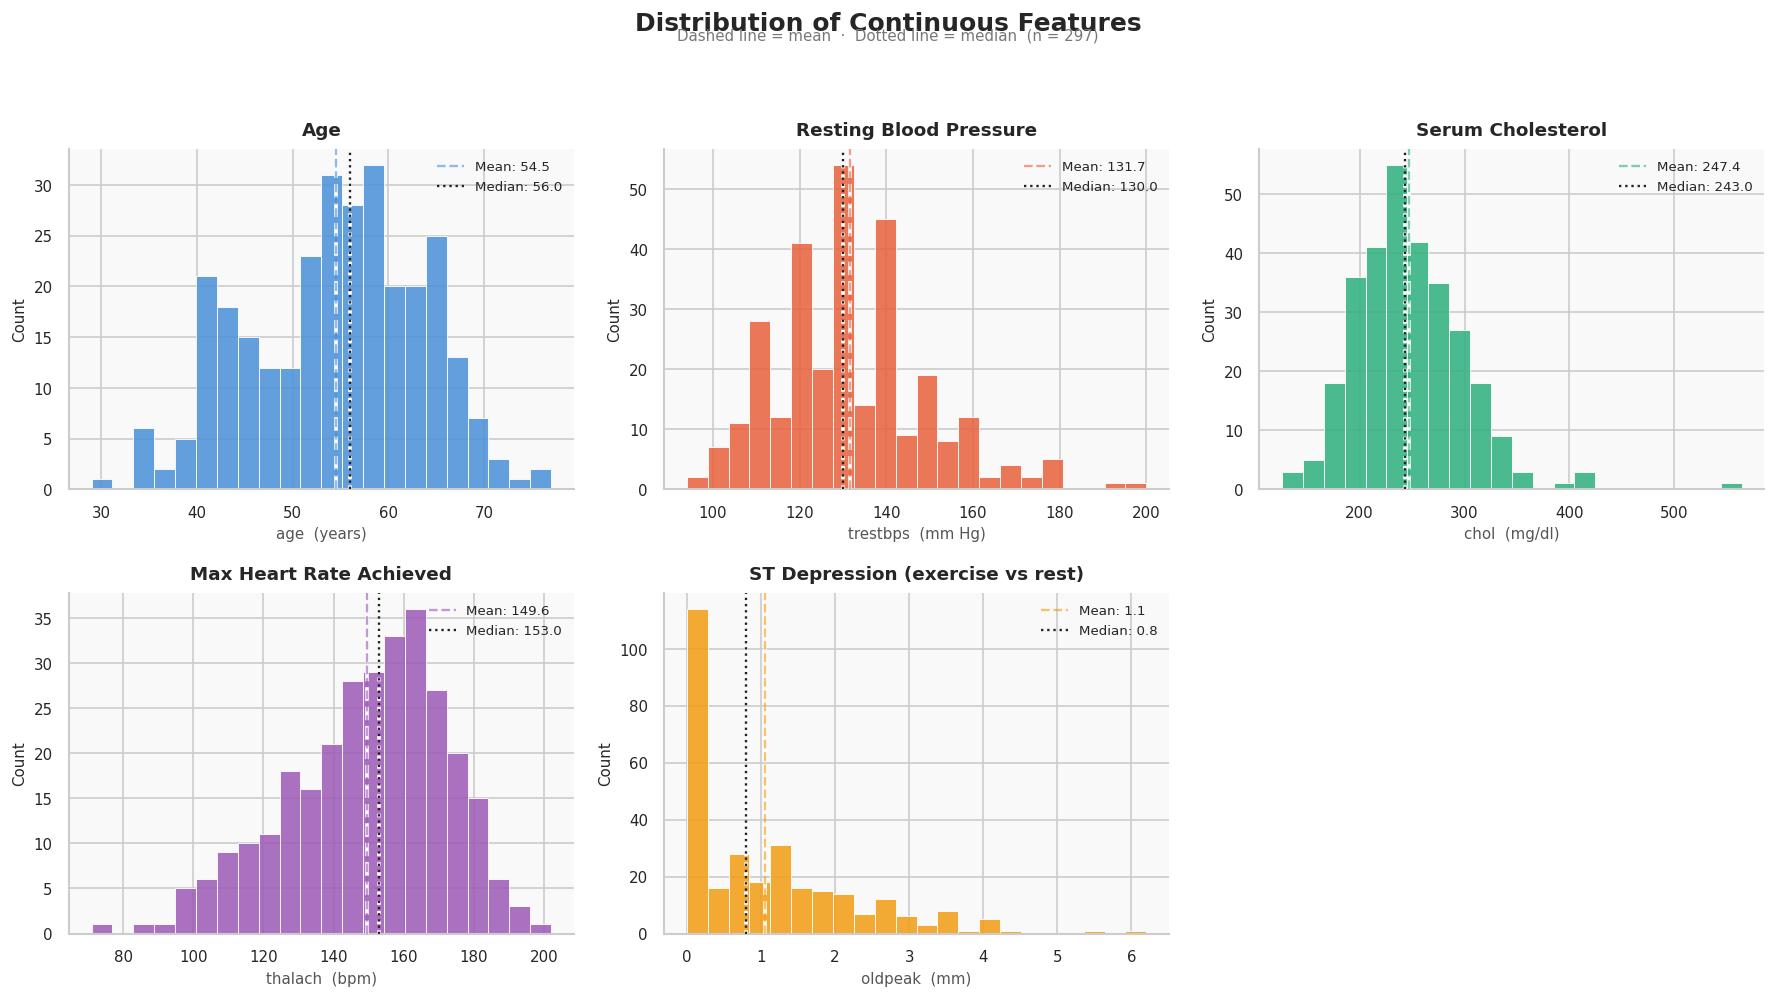

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
feature_meta = {
    'age':      ('Age', 'years'),
    'trestbps': ('Resting Blood Pressure', 'mm Hg'),
    'chol':     ('Serum Cholesterol', 'mg/dl'),
    'thalach':  ('Max Heart Rate Achieved', 'bpm'),
    'oldpeak':  ('ST Depression (exercise vs rest)', 'mm'),
}

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    label, unit = feature_meta[feat]
    color = PALETTE[i]

    ax.hist(X[feat], bins=22, color=color, edgecolor='white', linewidth=0.6, alpha=0.85, zorder=2)

    mean_val   = X[feat].mean()
    median_val = X[feat].median()

    ax.axvline(mean_val,   color='white', linestyle='--', linewidth=2.2, zorder=3)
    ax.axvline(mean_val,   color=color,   linestyle='--', linewidth=1.4, alpha=0.6, zorder=4, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='white', linestyle=':',  linewidth=2.2, zorder=3)
    ax.axvline(median_val, color='#222222', linestyle=':', linewidth=1.4, zorder=4, label=f'Median: {median_val:.1f}')

    ax.set_title(label, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(f'{feat}  ({unit})', fontsize=9, color='#555555')
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8, loc='upper right', facecolor='white', framealpha=0.85, edgecolor='#dddddd')
    ax.set_facecolor('#f9f9f9')

axes[-1].set_visible(False)

fig.suptitle('Distribution of Continuous Features', fontsize=15, fontweight='bold', y=1.04)
fig.text(0.5, 1.01, 'Dashed line = mean  ·  Dotted line = median  (n = 297)',
         ha='center', fontsize=9, color='#777777', transform=fig.transFigure)

plt.tight_layout()
plt.show()

**Observations:**
- **`age`**: Roughly bell-shaped, centred around 54–55 years. Mean ≈ median, suggesting near-Gaussian distribution.
- **`trestbps`**: Approximately normal with a slight right tail; a few patients show very high resting BP (>180 mmHg), suggesting possible outliers.
- **`chol`**: Right-skewed distribution with notable high-end values (>400 mg/dl) - potential clinical outliers. Mean > median confirms the skew.
- **`thalach`**: Roughly bell-shaped but slightly left-skewed; patients cluster around 150–170 bpm.
- **`oldpeak`**: Strongly right-skewed, the majority of patients have values near 0, but a tail extends to 6.2.

---

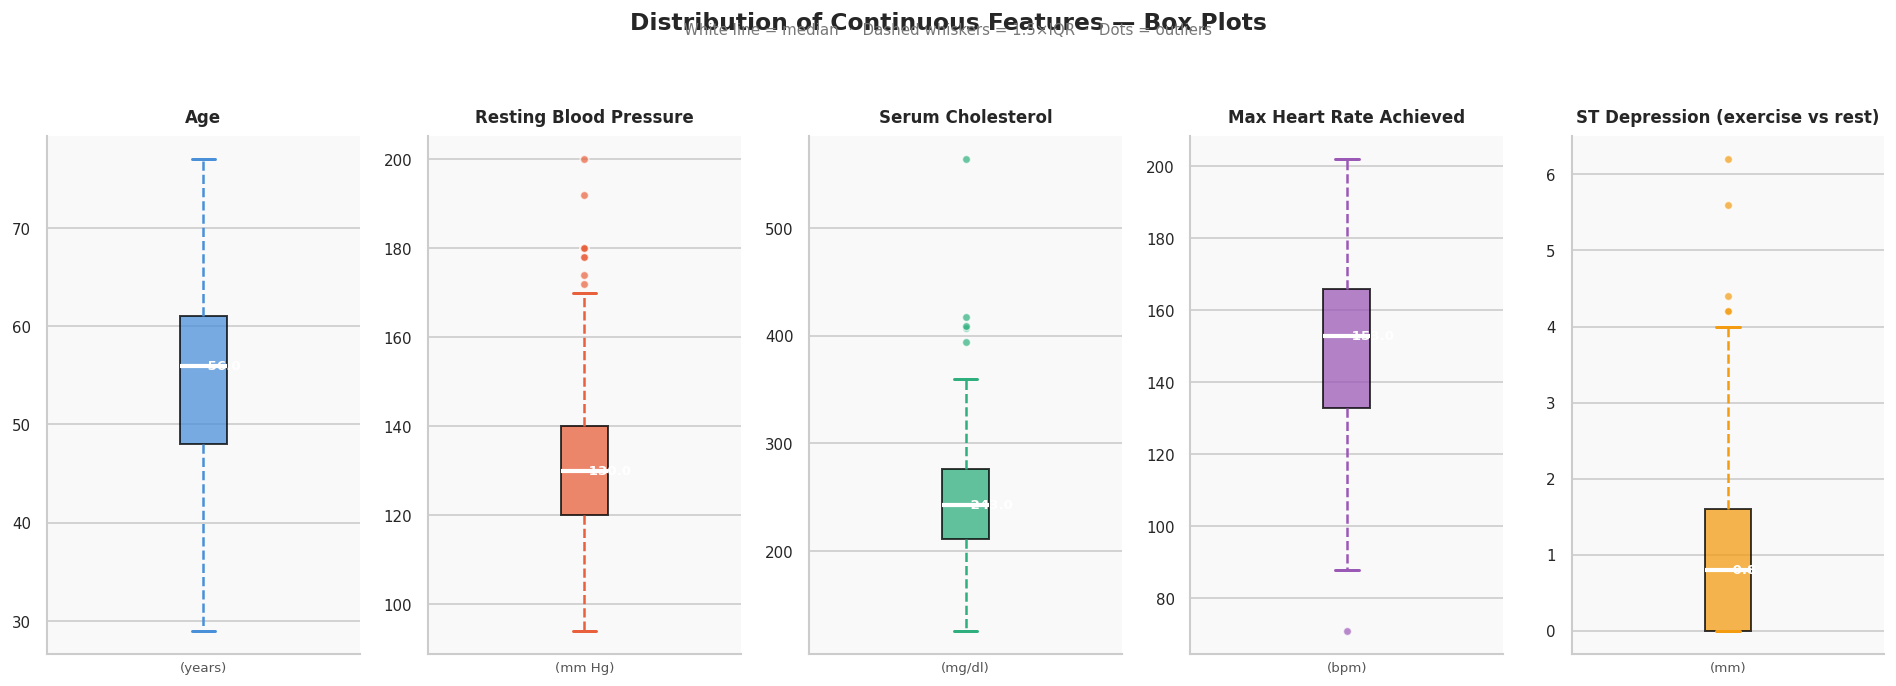

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5.5))

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    label, unit = feature_meta[feat]
    color = PALETTE[i]

    ax.boxplot(
        X[feat].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.75, linewidth=1.2),
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
        capprops=dict(color=color, linewidth=1.8),
        flierprops=dict(marker='o', markerfacecolor=color, markeredgecolor='white',
                        markersize=5, alpha=0.7, linewidth=0.5)
    )

    # Annotate median value
    median_val = X[feat].median()
    ax.text(1, median_val, f' {median_val:.1f}',
            va='center', ha='left', fontsize=8,
            color='white', fontweight='bold')

    ax.set_title(label, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(f'({unit})', fontsize=8, color='#555555')
    ax.set_xticks([])
    ax.set_facecolor('#f9f9f9')

fig.suptitle('Distribution of Continuous Features - Box Plots',
             fontsize=14, fontweight='bold', y=1.04)
fig.text(0.5, 1.005, 'White line = median  ·  Dashed whiskers = 1.5×IQR  ·  Dots = outliers',
         ha='center', fontsize=9, color='#777777', transform=fig.transFigure)

plt.tight_layout()
plt.show()

**Plot observations:**

These plots distribution align with the observed statistical measurements previously commented, but in a visually and more intuitive way.

- **`trestbps`**: Some high-BP outliers present (>180 mm Hg); they can be plausible as hypertensive crisis values in a cardiac patient cohort ³. They are retained and unmodified.
- **`chol`**: Similarly, it has several high-end outliers. These could be data errors, but since extreme cholesterol levels are physiologically possible ⁴. These will be retained too.

- **`oldpeak`**: Most values close to 0 but the whisker and outliers extend far right, confirming the heavy right skew.

- **`thalach`** and **`age`**: Clean distributions with few outliers.


---
#### Categorical and Binary Features

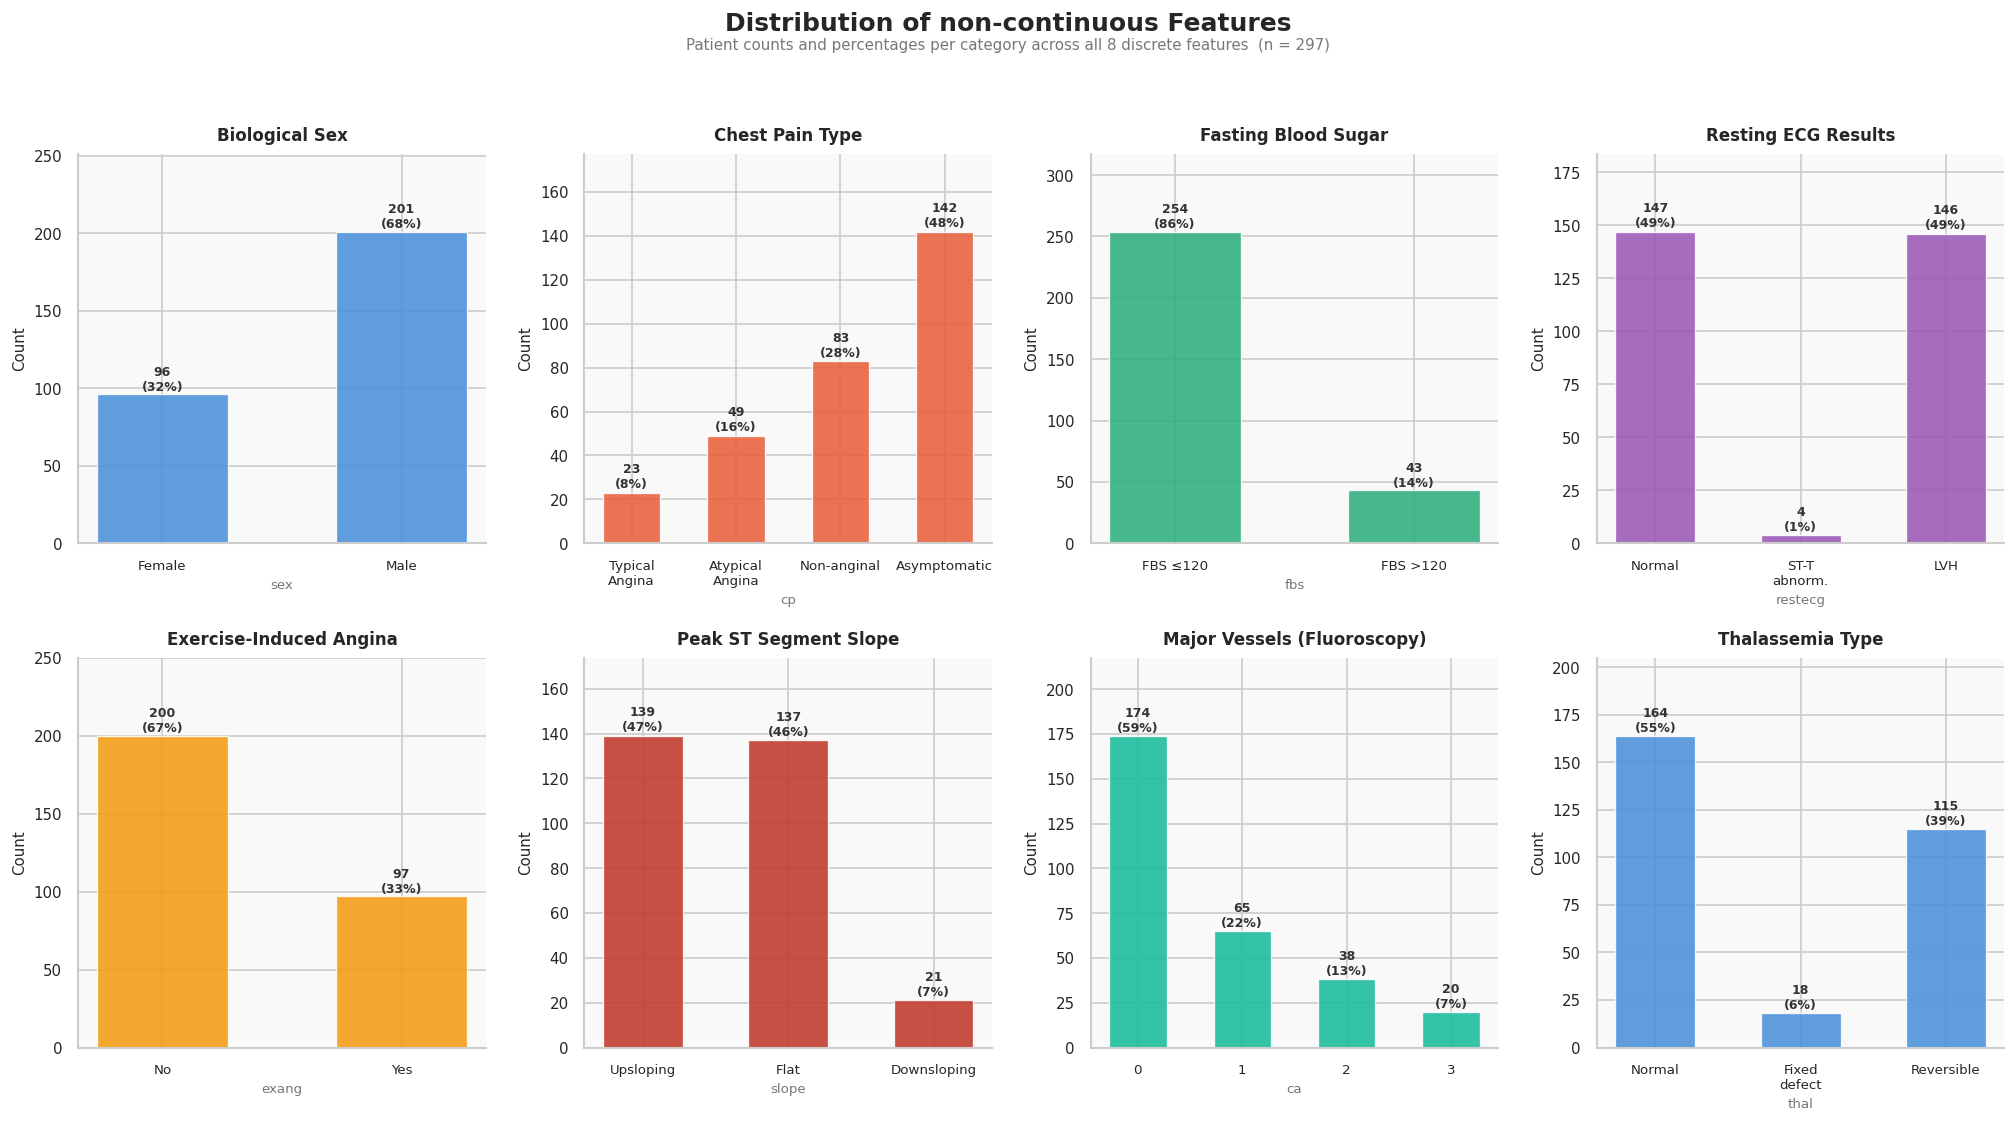

In [16]:
tick_labels = {
    'sex':     {0: 'Female', 1: 'Male'},
    'cp':      {1: 'Typical\nAngina', 2: 'Atypical\nAngina', 3: 'Non-anginal', 4: 'Asymptomatic'},
    'fbs':     {0: 'FBS ≤120', 1: 'FBS >120'},
    'restecg': {0: 'Normal', 1: 'ST-T\nabnorm.', 2: 'LVH'},
    'exang':   {0: 'No', 1: 'Yes'},
    'slope':   {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'ca':      {0: '0', 1: '1', 2: '2', 3: '3'},
    'thal':    {3: 'Normal', 6: 'Fixed\ndefect', 7: 'Reversible'}
}

feature_titles = {
    'sex':     'Biological Sex',
    'cp':      'Chest Pain Type',
    'fbs':     'Fasting Blood Sugar',
    'restecg': 'Resting ECG Results',
    'exang':   'Exercise-Induced Angina',
    'slope':   'Peak ST Segment Slope',
    'ca':      'Major Vessels (Fluoroscopy)',
    'thal':    'Thalassemia Type'
}

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
axes = axes.flatten()

for i, feat in enumerate(categorical_features):
    ax = axes[i]
    color = PALETTE[i % len(PALETTE)]

    counts = X[feat].value_counts().sort_index()
    labels = [tick_labels[feat].get(k, str(k)) for k in counts.index]
    total  = counts.sum()

    bars = ax.bar(labels, counts.values,
                  color=color, edgecolor='white',
                  linewidth=0.8, alpha=0.88, width=0.55, zorder=2)

    # Value + percentage labels on top of each bar
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val}\n({pct:.0f}%)',
                ha='center', va='bottom',
                fontsize=7.5, fontweight='bold', color='#333333')

    ax.set_title(feature_titles[feat], fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(feat, fontsize=8, color='#777777')
    ax.set_ylabel('Count', fontsize=9)
    ax.set_ylim(0, counts.max() * 1.25)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_facecolor('#f9f9f9')

fig.suptitle('Distribution of non-continuous Features',
             fontsize=15, fontweight='bold', y=1.04)
fig.text(0.5, 1.005, 'Patient counts and percentages per category across all 8 discrete features  (n = 297)',
         ha='center', fontsize=9, color='#777777', transform=fig.transFigure)

plt.tight_layout()
plt.show()

**Observations:**

The observations, again, do match the statistical comments from some sections above, but here, when visually comparing the different categories, the real difference can be better appreciated, for exaple, for **`sex`**, it was already mentioned that the dataset is male-dominant (~68% male), but this differnce is more highlighted when looking at the comparison plot. Same for the rest; Most patients (≈85%) have **`fbs`**: ≤120 mg/dl.
For **`restecg`**: the LVH category (type 2) is very rare. And the right-skewness of **`ca`** is clearly seen: most patients have 0 vessels, decreasing sharply.

---
### 1.10 Correlation Heatmap

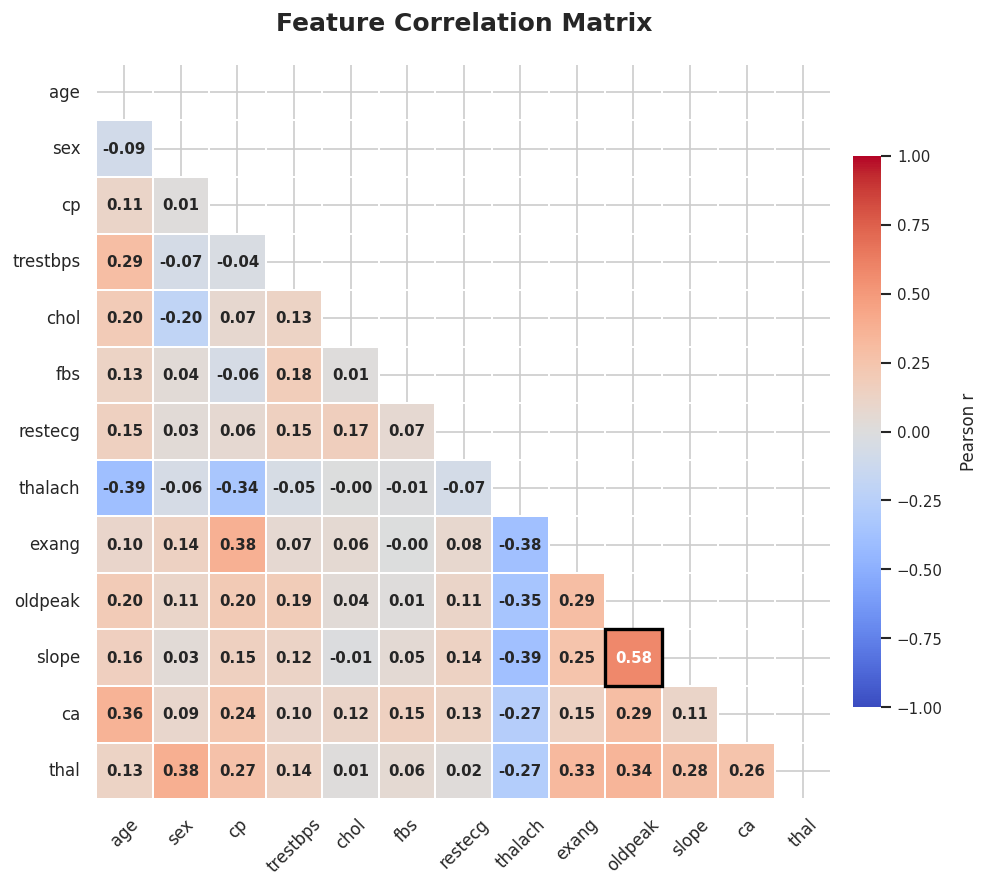

In [17]:
corr_matrix = X.corr()

# Nicer axis labels (replace raw variable names)
label_map = {
    'age': 'age', 'sex': 'sex', 'cp': 'cp',
    'trestbps': 'trestbps', 'chol': 'chol', 'fbs': 'fbs',
    'restecg': 'restecg', 'thalach': 'thalach', 'exang': 'exang',
    'oldpeak': 'oldpeak', 'slope': 'slope', 'ca': 'ca', 'thal': 'thal'
}

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap=PALETTE_DIV,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=1.2,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r', 'pad': 0.02}
)

# Highlight strong correlations with a border effect
for i in range(len(corr_matrix)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.4:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=False, edgecolor='black',
                linewidth=2, zorder=3
            ))

ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=20)

ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10, rotation=0)

# Style the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
cbar.set_label('Pearson r', fontsize=10, labelpad=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Observations:**
- `thalach` shows negative correlations with all variables. For example, for `age` (−0.40), `exang` (−0.38) and `oldpeak` (−0.34) could indicate older patients and those with exercise-induced symptoms achieve lower maximum heart rates.
- The strongest correlation in the dataset is `oldpeak`–`slope` (0.58).
- `fbs` and `restecg` show near-zero correlations with almost all features.

---
### 1.11 Task 1 Summary

| Item | Finding |
|---|---|
| **Shape** | 303 rows × 14 columns (13 features + target) → 297 after cleaning |
| **Missing values** | 6 rows (< 2%): `ca` (4), `thal` (2) - removed via listwise deletion |
| **Target** | Binarised (0 vs 1+) and stored separately as `y`; **not used in clustering** |
| **Skewed features** | `oldpeak`, `chol`, `ca` - right-skewed; will require robust/standard scaling |
| **Key correlations** | `oldpeak`–`slope` (−0.58), `thalach`–`age` (−0.40), `exang`–`oldpeak` (+0.58) |
| **Low-info features** | `fbs` has very limited variance (85% in one class); `restecg` LVH category rare |

**The cleaned feature matrix `X` (297 × 13) and binary target `y` (297,) are ready for Task 2 preprocessing.**

In [18]:
X.to_csv('X_clean.csv', index=False)
y.to_csv('y_clean.csv', index=False)
print('Saved X_clean.csv and y_clean.csv')

Saved X_clean.csv and y_clean.csv


---

### References
1. American Heart Association. (2023). *Heart Disease and Stroke Statistics Update*. Circulation.
2. Gibbons, R.J. et al. (2002). *ACC/AHA Guidelines for Exercise Testing*. Journal of the American College of Cardiology.
3. Whelton, P.K. et al. (2018). *2017 ACC/AHA Hypertension Guidelines*. Journal of the American College of Cardiology, 71(19), e127–e248.
4. National Cholesterol Education Program. (2002). *Third Report of the Expert Panel on Detection, Evaluation, and Treatment of High Blood Cholesterol in Adults (ATP III)*.
5. Detrano, R. et al. (1989). *International application of a new probability algorithm for the diagnosis of coronary artery disease*. American Journal of Cardiology. PMID: 2756873.
6. Tanaka, H. et al. (2001). *Age-predicted maximal heart rate revisited*. Journal of the American College of Cardiology, 37(1), 153–156.
7. Schafer, J.L. & Graham, J.W. (2002). *Missing data: Our view of the state of
the art*. Psychological Methods, 7(2), 147–177.